In [1]:
import pandas as pd

In [2]:
data = pd.read_csv("Fraud_processed.csv")
data.head()

,Transaction_ID,Customer_ID,Transaction_Date,Transaction_Amount,Merchant_Category,Payment_Method,Device_Type,Location,Is_International,Previous_Transactions,Average_Spend,Account_Age_Days,Suspicious_Keyword,Fraudulent,Hour,Day
0,T100000,CUST3252,2023-10-04 07:45:00,37.54,6,3,2,0,0,94,417.40,1492,0,0,7,Wednesday
1,T100001,CUST1630,2023-09-26 08:29:00,240.81,7,3,1,0,0,76,335.47,66,0,0,8,Tuesday
2,T100002,CUST7852,2023-07-18 15:54:00,105.34,1,1,1,0,0,60,432.03,216,0,0,15,Tuesday
3,T100003,CUST4892,2023-10-16 17:10:00,73.04,7,2,0,4,0,68,488.30,449,0,0,17,Monday
4,T100004,CUST8831,2023-09-09 00:46:00,13.57,7,0,0,0,0,57,437.03,754,0,0,0,Saturday


In [3]:
df = pd.DataFrame(data)
df.head()

,Transaction_ID,Customer_ID,Transaction_Date,Transaction_Amount,Merchant_Category,Payment_Method,Device_Type,Location,Is_International,Previous_Transactions,Average_Spend,Account_Age_Days,Suspicious_Keyword,Fraudulent,Hour,Day
0,T100000,CUST3252,2023-10-04 07:45:00,37.54,6,3,2,0,0,94,417.40,1492,0,0,7,Wednesday
1,T100001,CUST1630,2023-09-26 08:29:00,240.81,7,3,1,0,0,76,335.47,66,0,0,8,Tuesday
2,T100002,CUST7852,2023-07-18 15:54:00,105.34,1,1,1,0,0,60,432.03,216,0,0,15,Tuesday
3,T100003,CUST4892,2023-10-16 17:10:00,73.04,7,2,0,4,0,68,488.30,449,0,0,17,Monday
4,T100004,CUST8831,2023-09-09 00:46:00,13.57,7,0,0,0,0,57,437.03,754,0,0,0,Saturday


In [4]:
df.columns

Index(['Transaction_ID', 'Customer_ID', 'Transaction_Date',
       'Transaction_Amount', 'Merchant_Category', 'Payment_Method',
       'Device_Type', 'Location', 'Is_International', 'Previous_Transactions',
       'Average_Spend', 'Account_Age_Days', 'Suspicious_Keyword', 'Fraudulent',
       'Hour', 'Day'],
      dtype='object')

In [6]:
df

,Transaction_ID,Customer_ID,Transaction_Date,Transaction_Amount,Merchant_Category,Payment_Method,Device_Type,Location,Is_International,Previous_Transactions,Average_Spend,Account_Age_Days,Suspicious_Keyword,Fraudulent,Hour,Day
0,T100000,CUST3252,2023-10-04 07:45:00,37.54,6,3,2,0,0,94,417.40,1492,0,0,7,Wednesday
1,T100001,CUST1630,2023-09-26 08:29:00,240.81,7,3,1,0,0,76,335.47,66,0,0,8,Tuesday
2,T100002,CUST7852,2023-07-18 15:54:00,105.34,1,1,1,0,0,60,432.03,216,0,0,15,Tuesday
3,T100003,CUST4892,2023-10-16 17:10:00,73.04,7,2,0,4,0,68,488.30,449,0,0,17,Monday
4,T100004,CUST8831,2023-09-09 00:46:00,13.57,7,0,0,0,0,57,437.03,754,0,0,0,Saturday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,T104995,CUST3702,2023-08-01 21:20:00,182.15,0,1,1,4,0,13,277.99,840,0,0,21,Tuesday
4996,T104996,CUST6007,2024-01-14 16:42:00,10.17,2,0,0,1,0,128,477.24,441,0,0,16,Sunday
4997,T104997,CUST6812,2023-01-09 22:14:00,31.78,4,1,1,4,1,76,442.62,1474,0,1,22,Monday
4998,T104998,CUST9120,2023-08-18 17:15:00,135.31,7,1,1,0,0,13,73.33,246,0,0,17,Friday


# Data Cleaning

## Check Missing Value

In [13]:
df.isna().sum()

Transaction_ID           0
Customer_ID              0
Transaction_Date         0
Transaction_Amount       0
Merchant_Category        0
Payment_Method           0
Device_Type              0
Location                 0
Is_International         0
Previous_Transactions    0
Average_Spend            0
Account_Age_Days         0
Suspicious_Keyword       0
Fraudulent               0
Hour                     0
Day                      0
dtype: int64

## Check Duplicate Record

In [16]:
df.duplicated().sum()

0

## Check Class Distribution

In [19]:
df['Fraudulent'].value_counts()

Fraudulent
0    4518
1     482
Name: count, dtype: int64

# Feature Engineering 

## Extract More Time Features

In [23]:
df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'])

In [25]:
df['Month'] = df['Transaction_Date'].dt.month
df['Weekday'] = df['Transaction_Date'].dt.weekday
df['Is_Weekend'] = df['Weekday'].apply(lambda x: 1 if x >= 5 else 0)

In [27]:
df.iloc[:,-4:].head()

,Day,Month,Weekday,Is_Weekend
0,Wednesday,10,2,0
1,Tuesday,9,1,0
2,Tuesday,7,1,0
3,Monday,10,0,0
4,Saturday,9,5,1


## Spending Deviation Feature

In [30]:
df['Spend_Deviation'] = (
    df['Transaction_Amount'] - df['Average_Spend']
)

In [32]:
df['Spend_Ratio'] = (
    df['Transaction_Amount'] / (df['Average_Spend'] + 1)
)

## High Risk Transaction Flag

In [35]:
df['High_Value_Transaction'] = (
    df['Transaction_Amount'] > 500
).astype(int)

## Customer Activity Score

In [38]:
df['Customer_Activity_Score'] = (
    df['Previous_Transactions'] * df['Account_Age_Days']
)

## Risk Score Feature

In [41]:
df['Risk_Score'] = (
    df['Is_International'] +
    df['Suspicious_Keyword'] +
    df['High_Value_Transaction']
)

## Frequency Based Features

In [44]:
df['Transactions_Per_Day'] = (
    df['Previous_Transactions'] /
    (df['Account_Age_Days'] + 1)
)

# Exploratory Data Analysis (EDA)

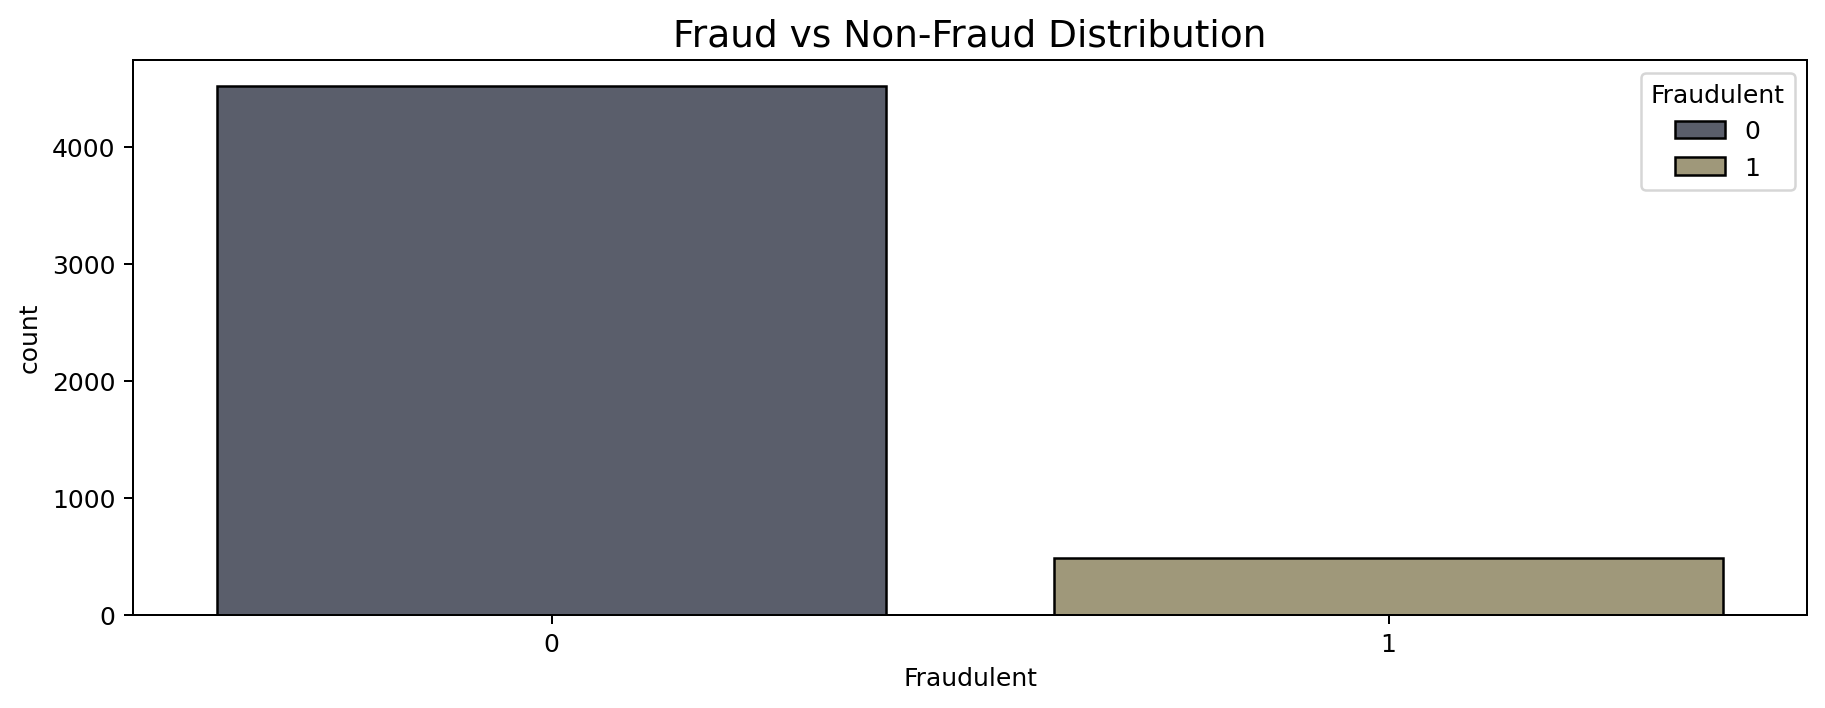

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12,4), dpi=180)
sns.countplot(x='Fraudulent', data=df, hue='Fraudulent', palette='cividis', ec='k')
plt.title("Fraud vs Non-Fraud Distribution", fontsize=15)
plt.show()

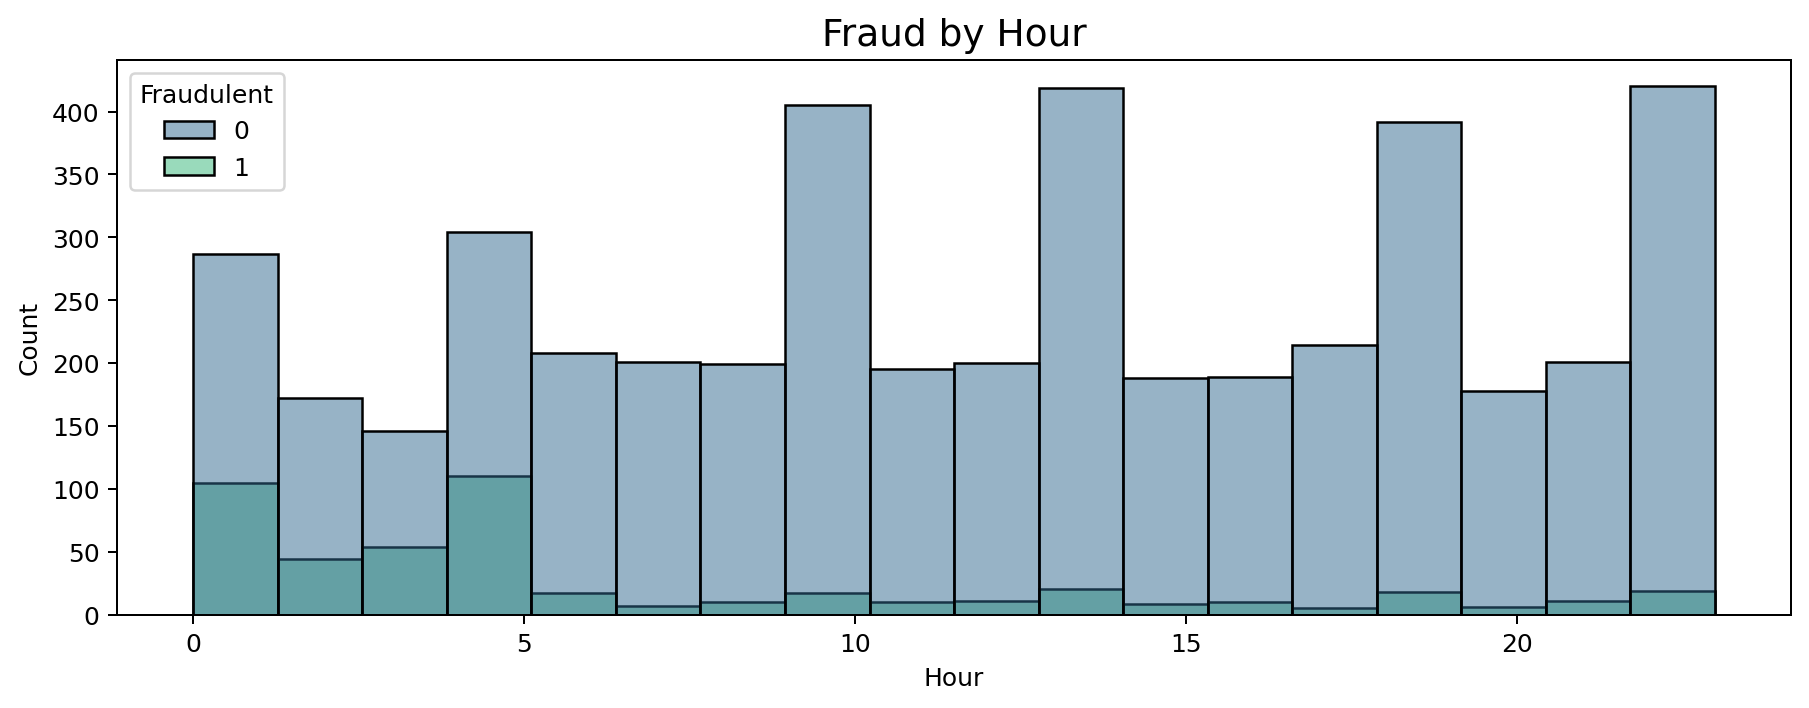

In [48]:
plt.figure(figsize=(12,4), dpi=180)
sns.histplot(data=df, x='Hour', hue='Fraudulent', palette='viridis', ec='k')
plt.title("Fraud by Hour", fontsize=15)
plt.show()

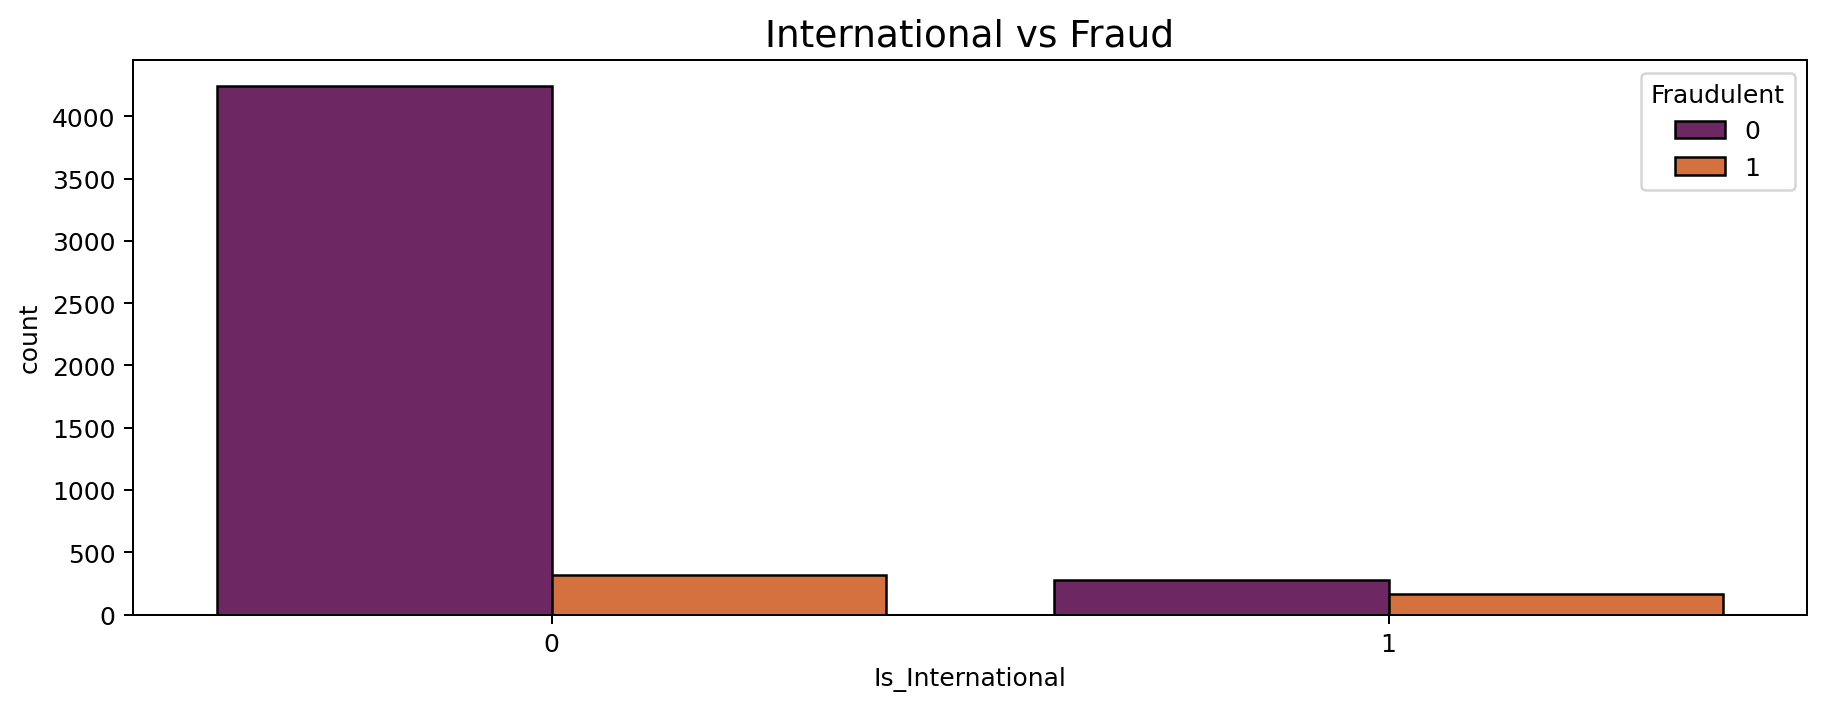

In [49]:
plt.figure(figsize=(12,4), dpi=180)
sns.countplot(x='Is_International', hue='Fraudulent', palette='inferno', ec='k', data=df)
plt.title("International vs Fraud", fontsize=15)
plt.show()

# Model Training

## Import Libraries

In [52]:
import pandas as pd
import numpy as np
import pickle

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [57]:
# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier
)
from xgboost import XGBClassifier

In [59]:
# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [61]:
# =========================================================
# DROP UNNECESSARY COLUMNS
# =========================================================

df.drop(
    columns=[
        "Transaction_ID",
        "Customer_ID",
        "Transaction_Date"
    ],
    inplace=True
)

# Features & Target

In [64]:
X = df.drop("Fraudulent", axis=1)
y = df["Fraudulent"]

In [66]:
df

,Transaction_Amount,Merchant_Category,Payment_Method,Device_Type,Location,Is_International,Previous_Transactions,Average_Spend,Account_Age_Days,Suspicious_Keyword,...,Day,Month,Weekday,Is_Weekend,Spend_Deviation,Spend_Ratio,High_Value_Transaction,Customer_Activity_Score,Risk_Score,Transactions_Per_Day
0,37.54,6,3,2,0,0,94,417.40,1492,0,...,Wednesday,10,2,0,-379.86,0.089723,0,140248,0,0.062960
1,240.81,7,3,1,0,0,76,335.47,66,0,...,Tuesday,9,1,0,-94.66,0.715695,0,5016,0,1.134328
2,105.34,1,1,1,0,0,60,432.03,216,0,...,Tuesday,7,1,0,-326.69,0.243263,0,12960,0,0.276498
3,73.04,7,2,0,4,0,68,488.30,449,0,...,Monday,10,0,0,-415.26,0.149274,0,30532,0,0.151111
4,13.57,7,0,0,0,0,57,437.03,754,0,...,Saturday,9,5,1,-423.46,0.030980,0,42978,0,0.075497
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,182.15,0,1,1,4,0,13,277.99,840,0,...,Tuesday,8,1,0,-95.84,0.652891,0,10920,0,0.015458
4996,10.17,2,0,0,1,0,128,477.24,441,0,...,Sunday,1,6,1,-467.07,0.021265,0,56448,0,0.289593
4997,31.78,4,1,1,4,1,76,442.62,1474,0,...,Monday,1,0,0,-410.84,0.071638,0,112024,1,0.051525
4998,135.31,7,1,1,0,0,13,73.33,246,0,...,Friday,8,4,0,61.98,1.820396,0,3198,0,0.052632


In [68]:
categorical_cols = [
    'Merchant_Category',
    'Payment_Method',
    'Device_Type',
    'Location',
    'Suspicious_Keyword',
    'Day'
]

numerical_cols = [
    'Transaction_Amount',
    'Is_International',
    'Previous_Transactions',
    'Average_Spend',
    'Account_Age_Days',
    'Hour',
    'Month',
    'Weekday',
    'Is_Weekend'
]

In [70]:
# =========================================================
# LABEL ENCODING
# =========================================================

label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

# Train-Test Split 

In [73]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [75]:
X_train.head()

,Transaction_Amount,Merchant_Category,Payment_Method,Device_Type,Location,Is_International,Previous_Transactions,Average_Spend,Account_Age_Days,Suspicious_Keyword,...,Day,Month,Weekday,Is_Weekend,Spend_Deviation,Spend_Ratio,High_Value_Transaction,Customer_Activity_Score,Risk_Score,Transactions_Per_Day
1876,71.40,6,2,0,6,0,40,93.23,1660,0,...,1,11,0,0,-21.83,0.757720,0,66400,0,0.024082
4538,6.81,1,0,1,0,0,133,369.79,446,0,...,5,1,1,0,-362.98,0.018366,0,59318,0,0.297539
4063,23.34,2,4,1,6,0,18,60.20,1088,0,...,0,12,4,0,-36.86,0.381373,0,19584,0,0.016529
2920,31.48,2,1,2,0,1,23,48.20,1763,0,...,6,5,2,0,-16.72,0.639837,0,40549,1,0.013039
937,196.55,4,0,0,5,0,166,414.31,1079,0,...,2,5,5,1,-217.76,0.473261,0,179114,0,0.153704


In [77]:
y_train.head()

1876    0
4538    0
4063    1
2920    1
937     0
Name: Fraudulent, dtype: int64

# Model Building

In [167]:
models = {
    
    "Logistic Regression": LogisticRegression(
        class_weight='balanced',
        max_iter=1000
    ),
    
    "Decision Tree": DecisionTreeClassifier(
        max_depth=10,
        random_state=42,
        class_weight='balanced'
    ),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42,
        class_weight='balanced'
    ),
    
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.1,
        max_depth=5,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=5,   # useful for imbalanced data
        random_state=42,
        eval_metric='logloss'
    )
}

# Results & Evaluate Models

In [181]:
results = []

best_model = None
best_score = 0
best_model_name = ""

print("\n================ MODEL TRAINING ================\n")

for name, model in models.items():
    
    print(f"\nTraining {name}...")
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    
    # Save Results
    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    })
    
    # Print Metrics
    print(f"Accuracy  : {accuracy:.2f}")
    print(f"Precision : {precision:.2f}")
    print(f"Recall    : {recall:.2f}")
    print(f"F1 Score  : {f1:.2f}")
    print(f"ROC-AUC   : {roc_auc:.2f}")
    
    # Save Best Model
    if roc_auc > best_score:
        best_score = roc_auc
        best_model = model
        best_model_name = name


================ MODEL TRAINING ================


Training Logistic Regression...
Accuracy  : 0.77
Precision : 0.26
Recall    : 0.74
F1 Score  : 0.38
ROC-AUC   : 0.86

Training Decision Tree...
Accuracy  : 0.79
Precision : 0.27
Recall    : 0.72
F1 Score  : 0.40
ROC-AUC   : 0.78

Training Random Forest...
Accuracy  : 0.86
Precision : 0.33
Recall    : 0.46
F1 Score  : 0.39
ROC-AUC   : 0.88

Training Gradient Boosting...
Accuracy  : 0.90
Precision : 0.44
Recall    : 0.20
F1 Score  : 0.27
ROC-AUC   : 0.88

Training XGBoost...
Accuracy  : 0.88
Precision : 0.33
Recall    : 0.29
F1 Score  : 0.31
ROC-AUC   : 0.87


# Results Table

In [184]:
results_df = pd.DataFrame(results)

print("\n================ MODEL COMPARISON ================\n")
print(results_df.sort_values(by="ROC-AUC", ascending=False).round(2))


================ MODEL COMPARISON ================

                 Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
3    Gradient Boosting      0.90       0.44    0.20      0.27     0.88
2        Random Forest      0.86       0.33    0.46      0.39     0.88
4              XGBoost      0.88       0.33    0.29      0.31     0.87
0  Logistic Regression      0.77       0.26    0.74      0.38     0.86
1        Decision Tree      0.79       0.27    0.72      0.40     0.78


# Best Model

In [187]:
# =========================================================
# BEST MODEL
# =========================================================

print("\nBest Model :", best_model_name)
print(f"Best ROC-AUC Score : {best_score:.2f}")


Best Model : Gradient Boosting
Best ROC-AUC Score : 0.88


# Classification report of best model 

In [189]:
best_pred = best_model.predict(X_test)

print("\n================ BEST MODEL REPORT ================\n")
print(classification_report(y_test, best_pred))


================ BEST MODEL REPORT ================

              precision    recall  f1-score   support

           0       0.92      0.97      0.95       904
           1       0.44      0.20      0.27        96

    accuracy                           0.90      1000
   macro avg       0.68      0.59      0.61      1000
weighted avg       0.87      0.90      0.88      1000



# Model Training

In [229]:
final_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000
)

In [231]:
final_model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

# Check Features Name

In [234]:
feature_names = X.columns.tolist()

print("Total Features:", len(feature_names))

for i, feature in enumerate(feature_names):
    print(i, feature)

Total Features: 21
0 Transaction_Amount
1 Merchant_Category
2 Payment_Method
3 Device_Type
4 Location
5 Is_International
6 Previous_Transactions
7 Average_Spend
8 Account_Age_Days
9 Suspicious_Keyword
10 Hour
11 Day
12 Month
13 Weekday
14 Is_Weekend
15 Spend_Deviation
16 Spend_Ratio
17 High_Value_Transaction
18 Customer_Activity_Score
19 Risk_Score
20 Transactions_Per_Day


# Model Saving

In [237]:
with open('fraud_detection_model.pkl', 'wb') as file:
    pickle.dump(final_model, file)

## Save Encoders

Because categorical values need encoding during prediction.

In [240]:
with open('encoders.pkl', 'wb') as file:
    pickle.dump(label_encoders, file)

## Save Feature Names

In [243]:
feature_names = X.columns.tolist()

with open('feature_names.pkl', 'wb') as file:
    pickle.dump(feature_names, file)

In [245]:
with open('feature_names.pkl', 'rb') as file:
    feature_names = pickle.load(file)

feature_names

['Transaction_Amount',
 'Merchant_Category',
 'Payment_Method',
 'Device_Type',
 'Location',
 'Is_International',
 'Previous_Transactions',
 'Average_Spend',
 'Account_Age_Days',
 'Suspicious_Keyword',
 'Hour',
 'Day',
 'Month',
 'Weekday',
 'Is_Weekend',
 'Spend_Deviation',
 'Spend_Ratio',
 'High_Value_Transaction',
 'Customer_Activity_Score',
 'Risk_Score',
 'Transactions_Per_Day']

In [247]:
import pickle
import pandas as pd
import numpy as np

# =========================
# LOAD MODEL
# =========================

with open('fraud_detection_model.pkl', 'rb') as file:
    model = pickle.load(file)

# =========================
# LOAD ENCODERS
# =========================

with open('encoders.pkl', 'rb') as file:
    encoders = pickle.load(file)

# =========================
# LOAD FEATURE NAMES
# =========================

with open('feature_names.pkl', 'rb') as file:
    feature_names = pickle.load(file)

# =========================
# MANUAL INPUT DATA
# =========================

input_data = {
    
    'Transaction_Amount': 25000,
    
    'Merchant_Category': 0,
    
    'Payment_Method': 0,
    
    'Device_Type': 1,
    
    'Location': 2,
    
    'Is_International': 1,
    
    'Previous_Transactions': 2,
    
    'Average_Spend': 5000,
    
    'Account_Age_Days': 20,
    
    'Suspicious_Keyword': 1,
    
    'Hour': 2,
    
    'Day': 15,
    
    'Month': 8,
    
    'Weekday': 4,
    
    'Spend_Deviation': abs(25000 - 5000),
    
    'Is_Night': 1,
    
    'Transaction_Ratio': 25000 / (2 + 1),

    'Is_Weekend': 1,
    
    'Spend_Deviation': -94.66,
    
    'Spend_Ratio': 0.7156,
    
    'High_Value_Transaction': 0,
    
    'Customer_Activity_Score': 5016,
    
    'Risk_Score': 0,

     'Transactions_Per_Day': 1.1343
}

# =========================
# ENCODE CATEGORICAL DATA
# =========================

categorical_cols = [
    'Merchant_Category',
    'Payment_Method',
    'Device_Type',
    'Location',
    'Suspicious_Keyword'
]

for col in categorical_cols:
    print(f"\n{col}")
    print(encoders[col].classes_)
    
# =========================
# CONVERT TO DATAFRAME
# =========================

input_df = pd.DataFrame([input_data])

# Ensure correct feature order
input_df = input_df[feature_names]

# =========================
# PREDICTION
# =========================

prediction = model.predict(input_df)[0]

# Fraud probability
probability = model.predict_proba(input_df)[0][1]

# =========================
# OUTPUT
# =========================

print("\n========== FRAUD DETECTION RESULT ==========")

if prediction == 1:
    print("⚠ Fraudulent Transaction Detected")
else:
    print("✓ Genuine Transaction")

print(f"\nFraud Probability: {probability:.2f}")

# =========================
# RISK LEVEL
# =========================

if probability >= 0.8:
    print("Risk Level: HIGH")
    
elif probability >= 0.5:
    print("Risk Level: MEDIUM")
    
else:
    print("Risk Level: LOW")


Merchant_Category
['0' '1' '2' '3' '4' '5' '6' '7']

Payment_Method
['0' '1' '2' '3' '4']

Device_Type
['0' '1' '2']

Location
['0' '1' '2' '3' '4' '5' '6']

Suspicious_Keyword
['0' '1']

========== FRAUD DETECTION RESULT ==========
✓ Genuine Transaction

Fraud Probability: 0.00
Risk Level: LOW


In [225]:
print(X_train.shape[1])
print(X.columns.tolist())

21
['Transaction_Amount', 'Merchant_Category', 'Payment_Method', 'Device_Type', 'Location', 'Is_International', 'Previous_Transactions', 'Average_Spend', 'Account_Age_Days', 'Suspicious_Keyword', 'Hour', 'Day', 'Month', 'Weekday', 'Is_Weekend', 'Spend_Deviation', 'Spend_Ratio', 'High_Value_Transaction', 'Customer_Activity_Score', 'Risk_Score', 'Transactions_Per_Day']


In [227]:
print(X.shape[1])
print(X.columns.tolist())

21
['Transaction_Amount', 'Merchant_Category', 'Payment_Method', 'Device_Type', 'Location', 'Is_International', 'Previous_Transactions', 'Average_Spend', 'Account_Age_Days', 'Suspicious_Keyword', 'Hour', 'Day', 'Month', 'Weekday', 'Is_Weekend', 'Spend_Deviation', 'Spend_Ratio', 'High_Value_Transaction', 'Customer_Activity_Score', 'Risk_Score', 'Transactions_Per_Day']
